In [2]:
import requests
import pandas as pd
from pathlib import Path


In [3]:
#Lagoa do Ouro - PE
LATITUDE = -9.1269
LONGITUDE = -36.46

START_DATE = "2024-01-01"
END_DATE = "2025-12-01"

ARCH_URL = "https://archive-api.open-meteo.com/v1/archive" 

In [4]:
def extract_weather_data(lat, lon, st_dt, end_dt, url):
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": st_dt,
        "end_date": end_dt,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "America/Sao_Paulo" 
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        raise Exception(f"API request failed: {response.status_code} - {response.text}")
    
    return response.json()

raw_json = extract_weather_data(LATITUDE, LONGITUDE, START_DATE, END_DATE, ARCH_URL)

In [5]:
def transform_data(json_data):
    hourly_data = json_data["hourly"]

    df = pd.DataFrame(hourly_data)

    df["time"] = pd.to_datetime(df["time"])

    column_map = {
        "temperature_2m": "temperature",
        "relative_humidity_2m": "humidity_pc",
        "precipitation": "precip_mm",
        "wind_speed_10m": "wind_speed_kmh"
    }

    df = df.rename(columns=column_map)

    df = df.dropna()

    return df

df = transform_data(raw_json)
print(df)

                     time  temperature  humidity_pc  precip_mm  wind_speed_kmh
0     2024-01-01 00:00:00         22.5           86        0.0             8.7
1     2024-01-01 01:00:00         22.0           89        0.0             7.7
2     2024-01-01 02:00:00         21.2           93        0.0             7.8
3     2024-01-01 03:00:00         20.7           96        0.0             6.5
4     2024-01-01 04:00:00         20.5           96        0.0             6.8
...                   ...          ...          ...        ...             ...
16819 2025-12-01 19:00:00         22.7           70        0.0            18.5
16820 2025-12-01 20:00:00         21.5           78        0.0            17.8
16821 2025-12-01 21:00:00         20.8           87        0.0            17.7
16822 2025-12-01 22:00:00         20.4           90        0.0            16.5
16823 2025-12-01 23:00:00         19.9           93        0.0            15.0

[16824 rows x 5 columns]


In [6]:
def load_data(df, path_str):
    path = Path(path_str)

    path.parent.mkdir(parents=True, exist_ok=True)

    df.to_csv(path, index=False)

    print(f"Data saved to: {path}\nShape: {df.shape}")

path = "data/weather.csv"

load_data(df, path)

Data saved to: data\weather.csv
Shape: (16824, 5)


In [7]:
#training the model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [8]:
csv = Path(path)
df = pd.read_csv(csv, parse_dates=["time"])

df["hour"] = df["time"].dt.hour
df["month"] = df["time"].dt.month
df["day_of_the_year"] = df["time"].dt.dayofyear

x = df.drop(columns=["time", "temperature"])

y = df["temperature"]

print("Features (X):")
print(x.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   humidity_pc  precip_mm  wind_speed_kmh  hour  month  day_of_the_year
0           86        0.0             8.7     0      1                1
1           89        0.0             7.7     1      1                1
2           93        0.0             7.8     2      1                1
3           96        0.0             6.5     3      1                1
4           96        0.0             6.8     4      1                1

Target (y):
0    22.5
1    22.0
2    21.2
3    20.7
4    20.5
Name: temperature, dtype: float64


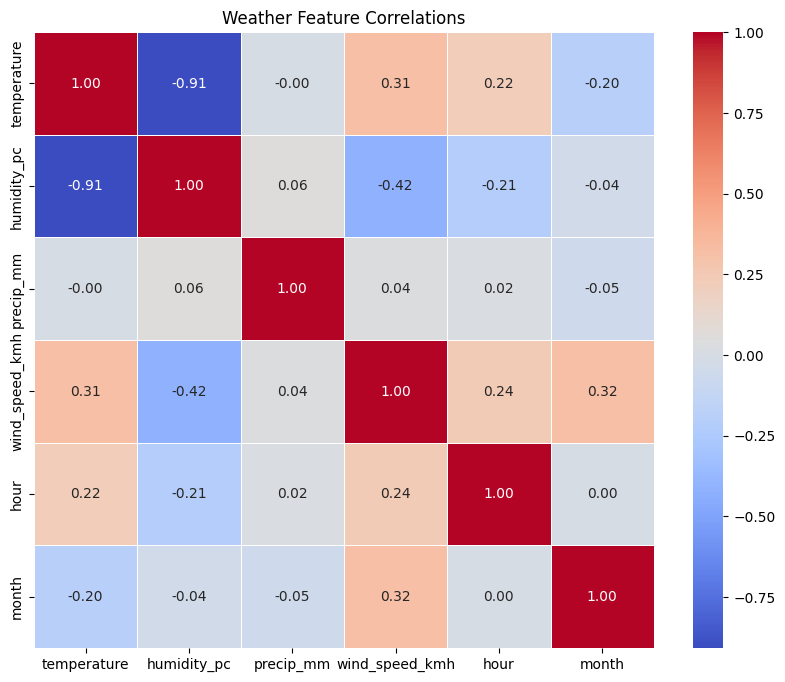

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["temperature", "humidity_pc", "precip_mm", "wind_speed_kmh", "hour", "month"]
corr = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Weather Feature Correlations")
plt.show()

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"training Set shape: {x_train.shape}")
print(f"testing Set shape:  {x_test.shape}")

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(x_train, y_train)


training Set shape: (13459, 6)
testing Set shape:  (3365, 6)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

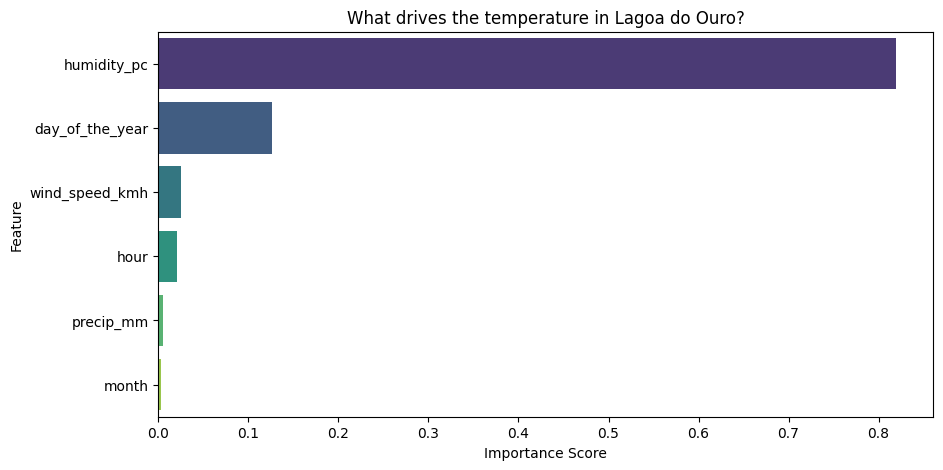

In [17]:
importances = model.feature_importances_
feature_names = x.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=fi_df, hue='feature', palette='viridis', legend=False)
plt.title("What drives the temperature in Lagoa do Ouro?")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [11]:
predictions = model.predict(x_test)

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE):  {mae:.2f} °C")
print(f"Mean Squared Error (MSE):   {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} °C")

Mean Absolute Error (MAE):  0.44 °C
Mean Squared Error (MSE):   0.34
Root Mean Squared Error (RMSE): 0.58 °C


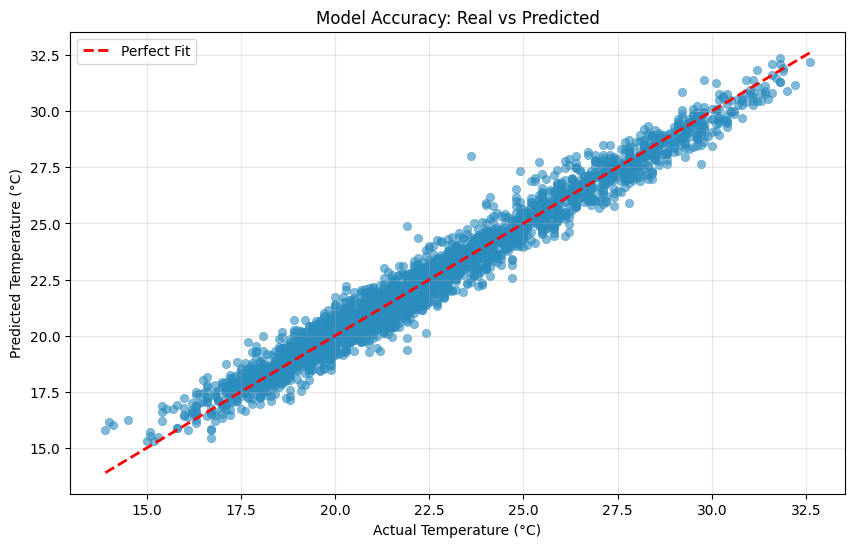

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=predictions, alpha=0.6, edgecolor=None, color="#2b8cbe")

min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Perfect Fit")

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Model Accuracy: Real vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
model_path = Path("models/weather_model.joblib")
model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(model, model_path)

print(f"model saved successfully to: {model_path}")

model saved successfully to: models\weather_model.joblib


In [13]:
FORECAST_URL = "https://api.open-meteo.com/v1/forecast"

def extract_forecast_data(lat, lon, url):
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "America/Sao_Paulo",
        "forecast_days": 1
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        raise Exception(f"API request failed: {response.status_code} - {response.text}")
    
    return response.json()

forecast_json = extract_forecast_data(LATITUDE, LONGITUDE, FORECAST_URL)


In [23]:
def prepare_data(json_data):
    hourly_data = json_data["hourly"]

    df = pd.DataFrame(hourly_data)

    df["time"] = pd.to_datetime(df["time"])

    

    column_map = {
        "temperature_2m": "open_meteo_temp",
        "relative_humidity_2m": "humidity_pc",
        "precipitation": "precip_mm",
        "wind_speed_10m": "wind_speed_kmh"
    }

    df["hour"] = df["time"].dt.hour
    df["month"] = df["time"].dt.month
    df["day_of_the_year"] = df["time"].dt.dayofyear

    df = df.rename(columns=column_map)

    df = df.dropna()

    return df

data = prepare_data(forecast_json)

In [24]:
model_path = Path("models/weather_model.joblib")

loaded_model = joblib.load(model_path)

features = ["humidity_pc", "precip_mm", "wind_speed_kmh", "hour", "month", "day_of_the_year"]
x_future = data[features]

predicted_temps = loaded_model.predict(x_future)

data["model_predictions"] = predicted_temps

view_cols = ["time", "open_meteo_temp", "model_predictions"]
print(data[view_cols].head(10))


                 time  open_meteo_temp  model_predictions
0 2025-12-15 00:00:00             20.0             21.052
1 2025-12-15 01:00:00             19.8             21.090
2 2025-12-15 02:00:00             19.6             21.061
3 2025-12-15 03:00:00             19.2             20.907
4 2025-12-15 04:00:00             19.0             20.764
5 2025-12-15 05:00:00             18.9             20.637
6 2025-12-15 06:00:00             19.7             20.638
7 2025-12-15 07:00:00             21.8             23.296
8 2025-12-15 08:00:00             24.3             25.473
9 2025-12-15 09:00:00             27.0             28.117
